# HW2a CNN Autoencoder

This notebook runs the complete Fashion-MNIST anomaly-detection pipeline. Classes 0–5 are normal training examples; classes 6–9 are suspicious evaluation examples. The model uses reconstruction MSE as its anomaly score.

In [1]:
# Install once in a fresh environment if needed
# %pip install torch torchvision matplotlib numpy scikit-learn python-docx

In [3]:
!pip install -q matplotlib numpy scikit-learn python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 4.7 MB/s eta 0:00:00


In [4]:
from google.colab import files

uploaded = files.upload()

Saving autoencoder_invoice_anomaly.py to autoencoder_invoice_anomaly.py
Saving make_report.py to make_report.py


In [5]:
!ls -l

total 16
-rw-r--r-- 1 root root 8186 Oct  6 23:00 autoencoder_invoice_anomaly.py
-rw-r--r-- 1 root root 3090 Oct  6 23:00 make_report.py
drwxr-xr-x 1 root root 4096 Oct  2 13:50 sample_data


In [6]:
!python autoencoder_invoice_anomaly.py \
    --epochs 5 \
    --max-normal 12000 \
    --max-anomaly 4000 \
    --out outputs

100% 26.4M/26.4M [00:01<00:00, 17.9MB/s]
100% 29.5k/29.5k [00:00<00:00, 268kB/s]
100% 4.42M/4.42M [00:00<00:00, 4.91MB/s]
100% 5.15k/5.15k [00:00<00:00, 31.2MB/s]
conv epoch 1/5: 0.147487
conv epoch 2/5: 0.030966
conv epoch 3/5: 0.016815
conv epoch 4/5: 0.012595
conv epoch 5/5: 0.010528
dense epoch 1/5: 0.080057
dense epoch 2/5: 0.039094
dense epoch 3/5: 0.030438
dense epoch 4/5: 0.025655
dense epoch 5/5: 0.023252
{
  "config": {
    "data": "data",
    "out": "outputs",
    "epochs": 5,
    "batch_size": 128,
    "max_normal": 12000,
    "max_anomaly": 4000,
    "normal_val": 1500,
    "bottleneck": 8,
    "latent_dim": 32,
    "percentile": 95,
    "seed": 42,
    "cpu": false,
    "device": "cpu",
    "train_count": 10500,
    "normal_val_count": 1500,
    "anomaly_eval_count": 500
  },
  "conv": {
    "history": [
      0.1474866029577596,
      0.030965981548031173,
      0.01681450496294669,
      0.012595267616567157,
      0.010527866615425973
    ],
    "threshold": 0.01880816

In [7]:
!python make_report.py \
    --metrics outputs/metrics.json \
    --out HW2aCNNautoencoder_report.docx

In [8]:
from google.colab import files
files.download("HW2aCNNautoencoder_report.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

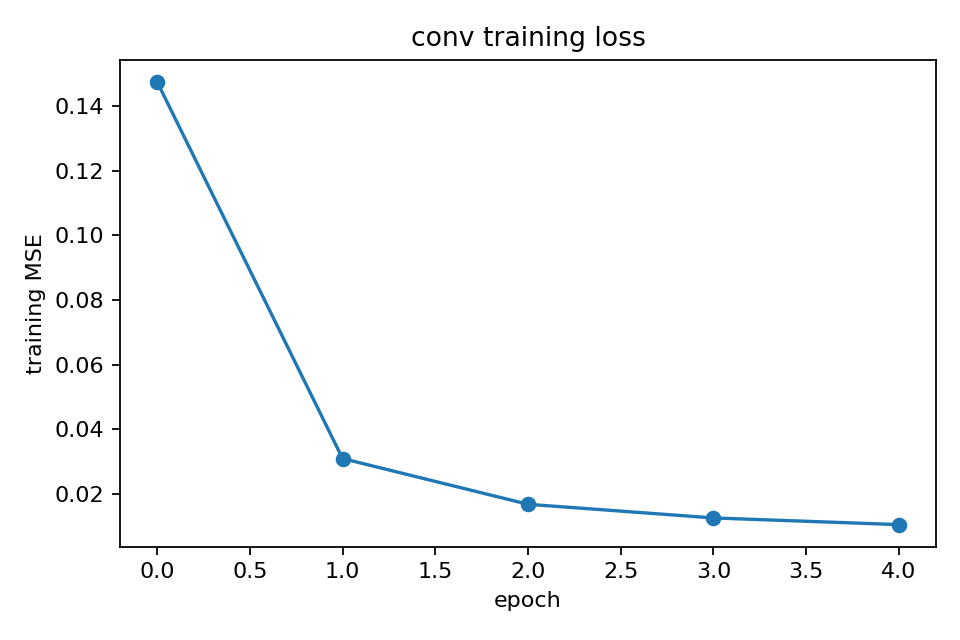

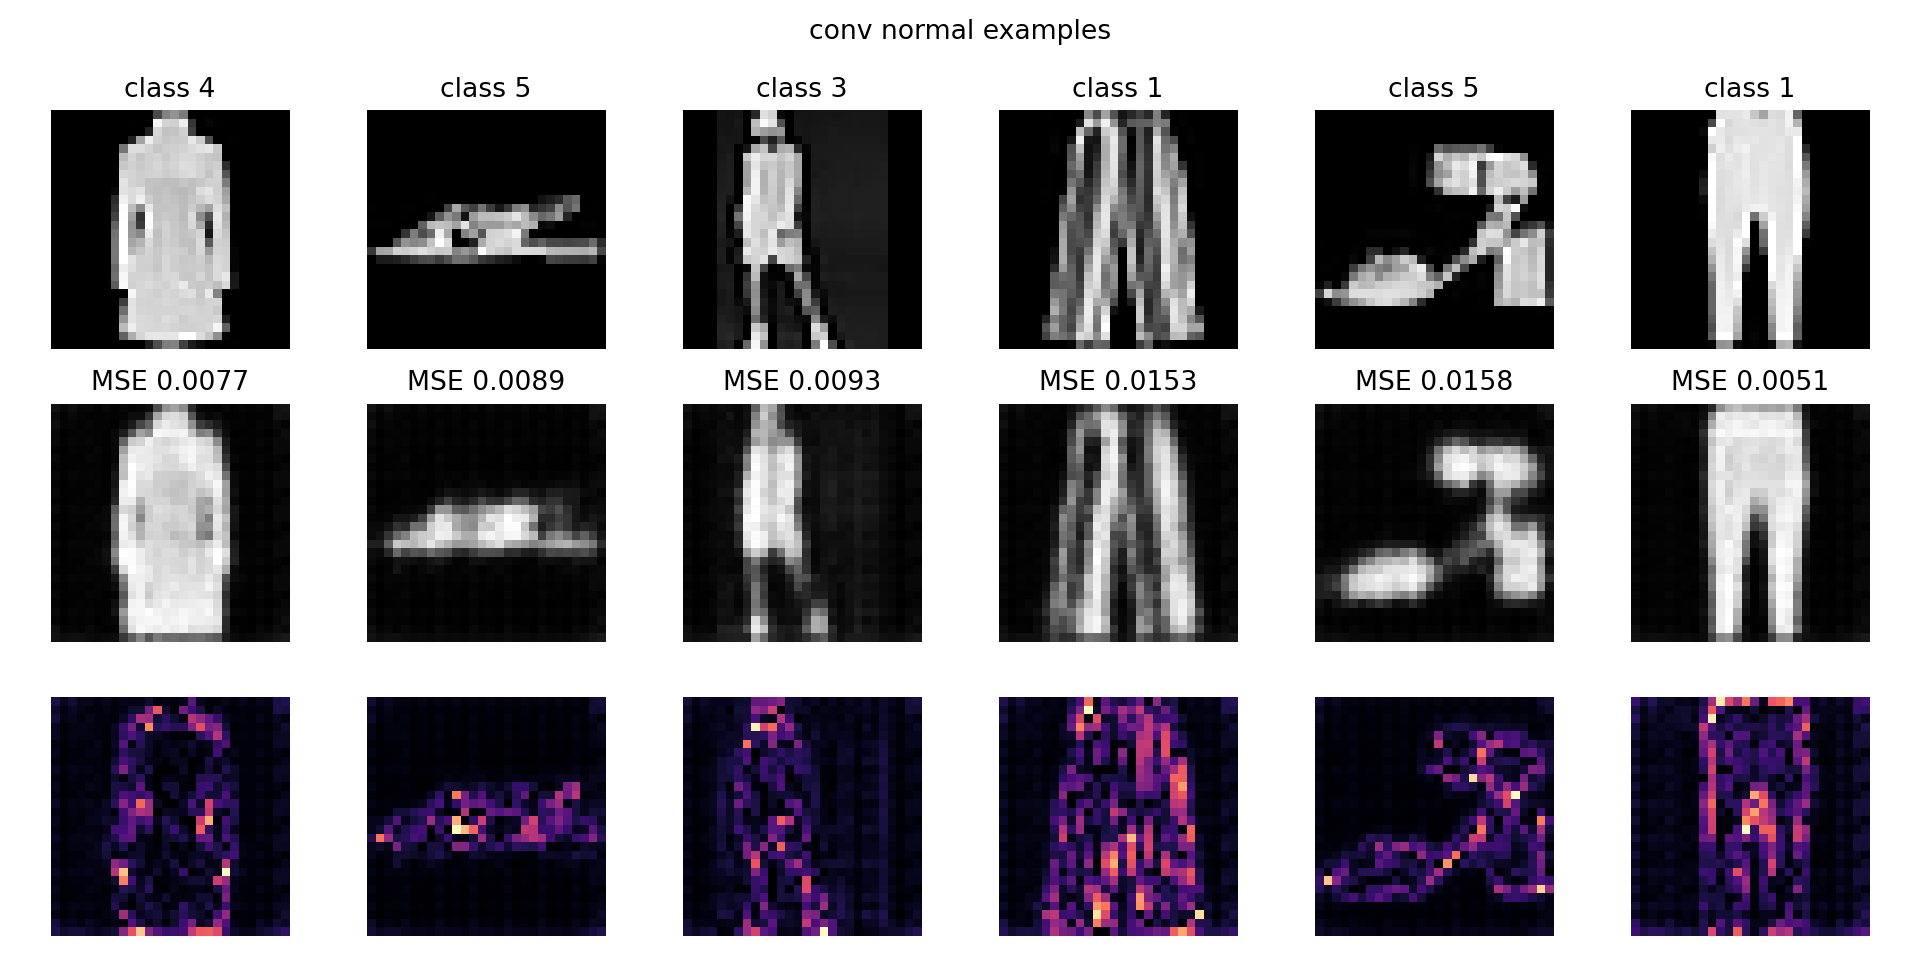

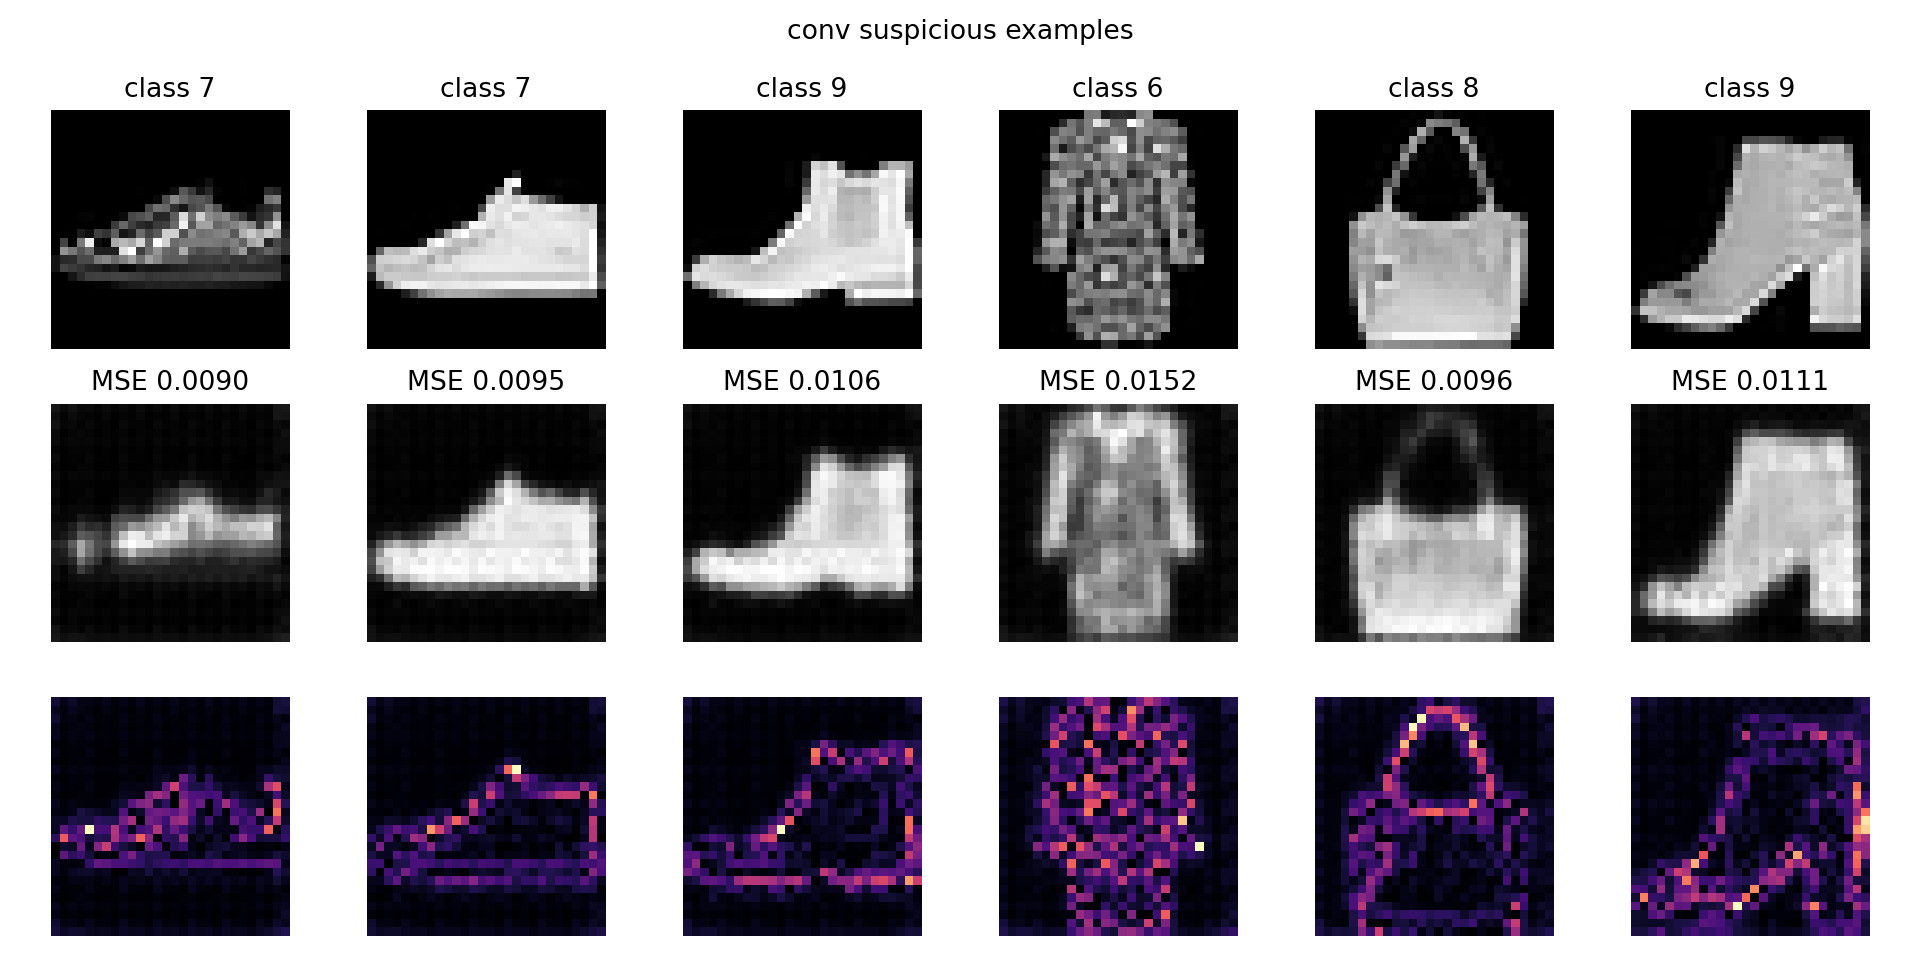

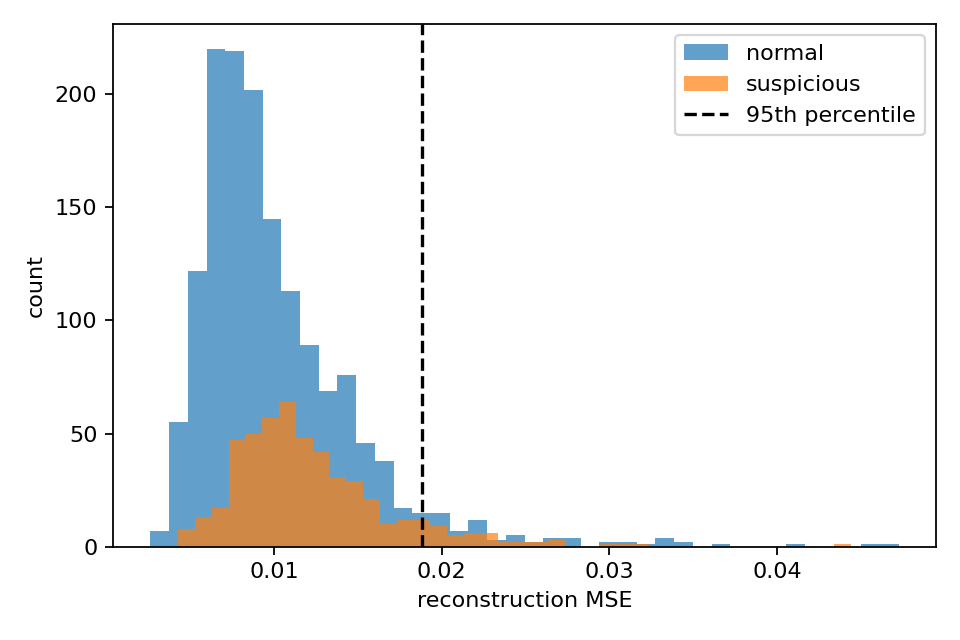

In [9]:
from IPython.display import display, Image

display(Image(filename="outputs/conv_loss.png"))
display(Image(filename="outputs/conv_normal_examples.png"))
display(Image(filename="outputs/conv_anomaly_examples.png"))
display(Image(filename="outputs/conv_error_distribution.png"))

In [10]:
from pathlib import Path
import sys
ROOT = Path.cwd()
if not (ROOT / 'autoencoder_invoice_anomaly.py').exists():
    raise FileNotFoundError('Run this notebook from the folder containing autoencoder_invoice_anomaly.py')
print(ROOT)

/content


In [11]:
!python make_report.py \
    --metrics /content/outputs/metrics.json \
    --out /content/HW2aCNNautoencoder_report.docx

In [12]:
!ls -lh /content/HW2aCNNautoencoder_report.docx

-rw-r--r-- 1 root root 202K Oct  6 23:06 /content/HW2aCNNautoencoder_report.docx


In [13]:
!ls -lh /content/outputs

total 4.5M
-rw-r--r-- 1 root root  72K Oct  6 23:01 conv_anomaly_examples.png
-rw-r--r-- 1 root root  27K Oct  6 23:01 conv_error_distribution.png
-rw-r--r-- 1 root root  37K Oct  6 23:01 conv_loss.png
-rw-r--r-- 1 root root  69K Oct  6 23:01 conv_normal_examples.png
-rw-r--r-- 1 root root  64K Oct  6 23:01 conv_states.pt
-rw-r--r-- 1 root root  68K Oct  6 23:02 dense_anomaly_examples.png
-rw-r--r-- 1 root root  29K Oct  6 23:02 dense_error_distribution.png
-rw-r--r-- 1 root root  37K Oct  6 23:02 dense_loss.png
-rw-r--r-- 1 root root  64K Oct  6 23:02 dense_normal_examples.png
-rw-r--r-- 1 root root 4.1M Oct  6 23:02 dense_states.pt
-rw-r--r-- 1 root root 1.4K Oct  6 23:02 metrics.json


In [14]:
!python /content/make_report.py \
    --metrics /content/outputs/metrics.json \
    --out /content/HW2aCNNautoencoder_report.docx

In [15]:
from google.colab import files
files.download("/content/HW2aCNNautoencoder_report.docx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
!zip -r /content/HW2aCNNautoencoder_submission.zip \
    /content/HW2aCNNautoencoder.ipynb \
    /content/HW2aCNNautoencoder_report.docx \
    /content/outputs \
    /content/autoencoder_invoice_anomaly.py \
    /content/make_report.py \
    /content/requirements.txt

	zip warning: name not matched: /content/HW2aCNNautoencoder.ipynb
	zip warning: name not matched: /content/requirements.txt
  adding: content/HW2aCNNautoencoder_report.docx (deflated 1%)
  adding: content/outputs/ (stored 0%)
  adding: content/outputs/dense_loss.png (deflated 14%)
  adding: content/outputs/conv_normal_examples.png (deflated 21%)
  adding: content/outputs/conv_error_distribution.png (deflated 21%)
  adding: content/outputs/conv_loss.png (deflated 13%)
  adding: content/outputs/conv_states.pt (deflated 27%)
  adding: content/outputs/dense_anomaly_examples.png (deflated 20%)
  adding: content/outputs/dense_error_distribution.png (deflated 20%)
  adding: content/outputs/conv_anomaly_examples.png (deflated 20%)
  adding: content/outputs/metrics.json (deflated 61%)
  adding: content/outputs/dense_normal_examples.png (deflated 21%)
  adding: content/outputs/dense_states.pt (deflated 8%)
  adding: content/autoencoder_invoice_anomaly.py (deflated 65%)
  adding: content/make_rep

In [21]:
from google.colab import files
files.download("/content/HW2aCNNautoencoder_submission.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Run the experiment

The script stores one `state_dict` snapshot after every epoch, loss curves, reconstruction/error visualizations, and `metrics.json`. Increase `--epochs` to 10 for the full exercise or reduce `--max-normal` for a quick CPU smoke test.

In [16]:
!{sys.executable} autoencoder_invoice_anomaly.py --epochs 5 --max-normal 12000 --max-anomaly 4000 --out outputs

conv epoch 1/5: 0.147487
conv epoch 2/5: 0.030966
conv epoch 3/5: 0.016815
conv epoch 4/5: 0.012595
conv epoch 5/5: 0.010528
dense epoch 1/5: 0.080057
dense epoch 2/5: 0.039094
dense epoch 3/5: 0.030438
dense epoch 4/5: 0.025655
dense epoch 5/5: 0.023252
{
  "config": {
    "data": "data",
    "out": "outputs",
    "epochs": 5,
    "batch_size": 128,
    "max_normal": 12000,
    "max_anomaly": 4000,
    "normal_val": 1500,
    "bottleneck": 8,
    "latent_dim": 32,
    "percentile": 95,
    "seed": 42,
    "cpu": false,
    "device": "cpu",
    "train_count": 10500,
    "normal_val_count": 1500,
    "anomaly_eval_count": 500
  },
  "conv": {
    "history": [
      0.1474866029577596,
      0.030965981548031173,
      0.01681450496294669,
      0.012595267616567157,
      0.010527866615425973
    ],
    "threshold": 0.018808163702487946,
    "precision": 0.5,
    "recall": 0.09,
    "roc_auc": 0.67394,
    "confusion_matrix": [
      [
        955,
        45
      ],
      [
        45

In [17]:
import json
metrics = json.loads(Path('outputs/metrics.json').read_text())
for name in ('conv','dense'):
    r = metrics[name]
    print(name, {k:r[k] for k in ('threshold','precision','recall','roc_auc','confusion_matrix')})

conv {'threshold': 0.018808163702487946, 'precision': 0.5, 'recall': 0.09, 'roc_auc': 0.67394, 'confusion_matrix': [[955, 45], [455, 45]]}
dense {'threshold': 0.047056686133146286, 'precision': 0.7513227513227513, 'recall': 0.284, 'roc_auc': 0.770824, 'confusion_matrix': [[953, 47], [358, 142]]}


## How to read the confusion matrix

Rows are the true labels `[normal, suspicious]`; columns are the predicted labels `[normal, suspicious]`. Thus the top-right value is a false alarm and the bottom-left value is a missed anomaly. The threshold is the 95th percentile of normal validation errors, so approximately 5% of normal validation examples may be flagged by design.

conv_loss.png


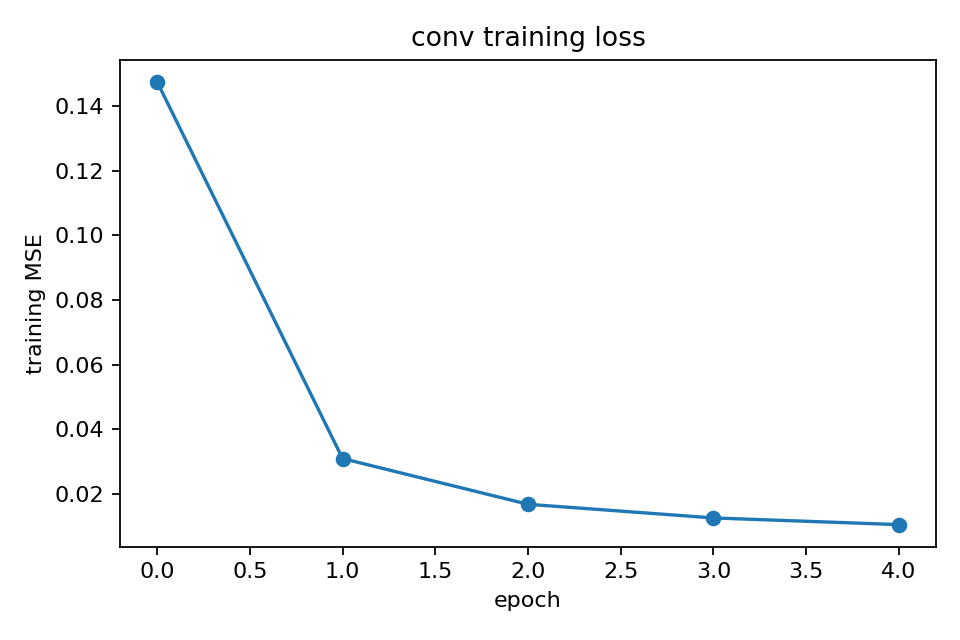

conv_normal_examples.png


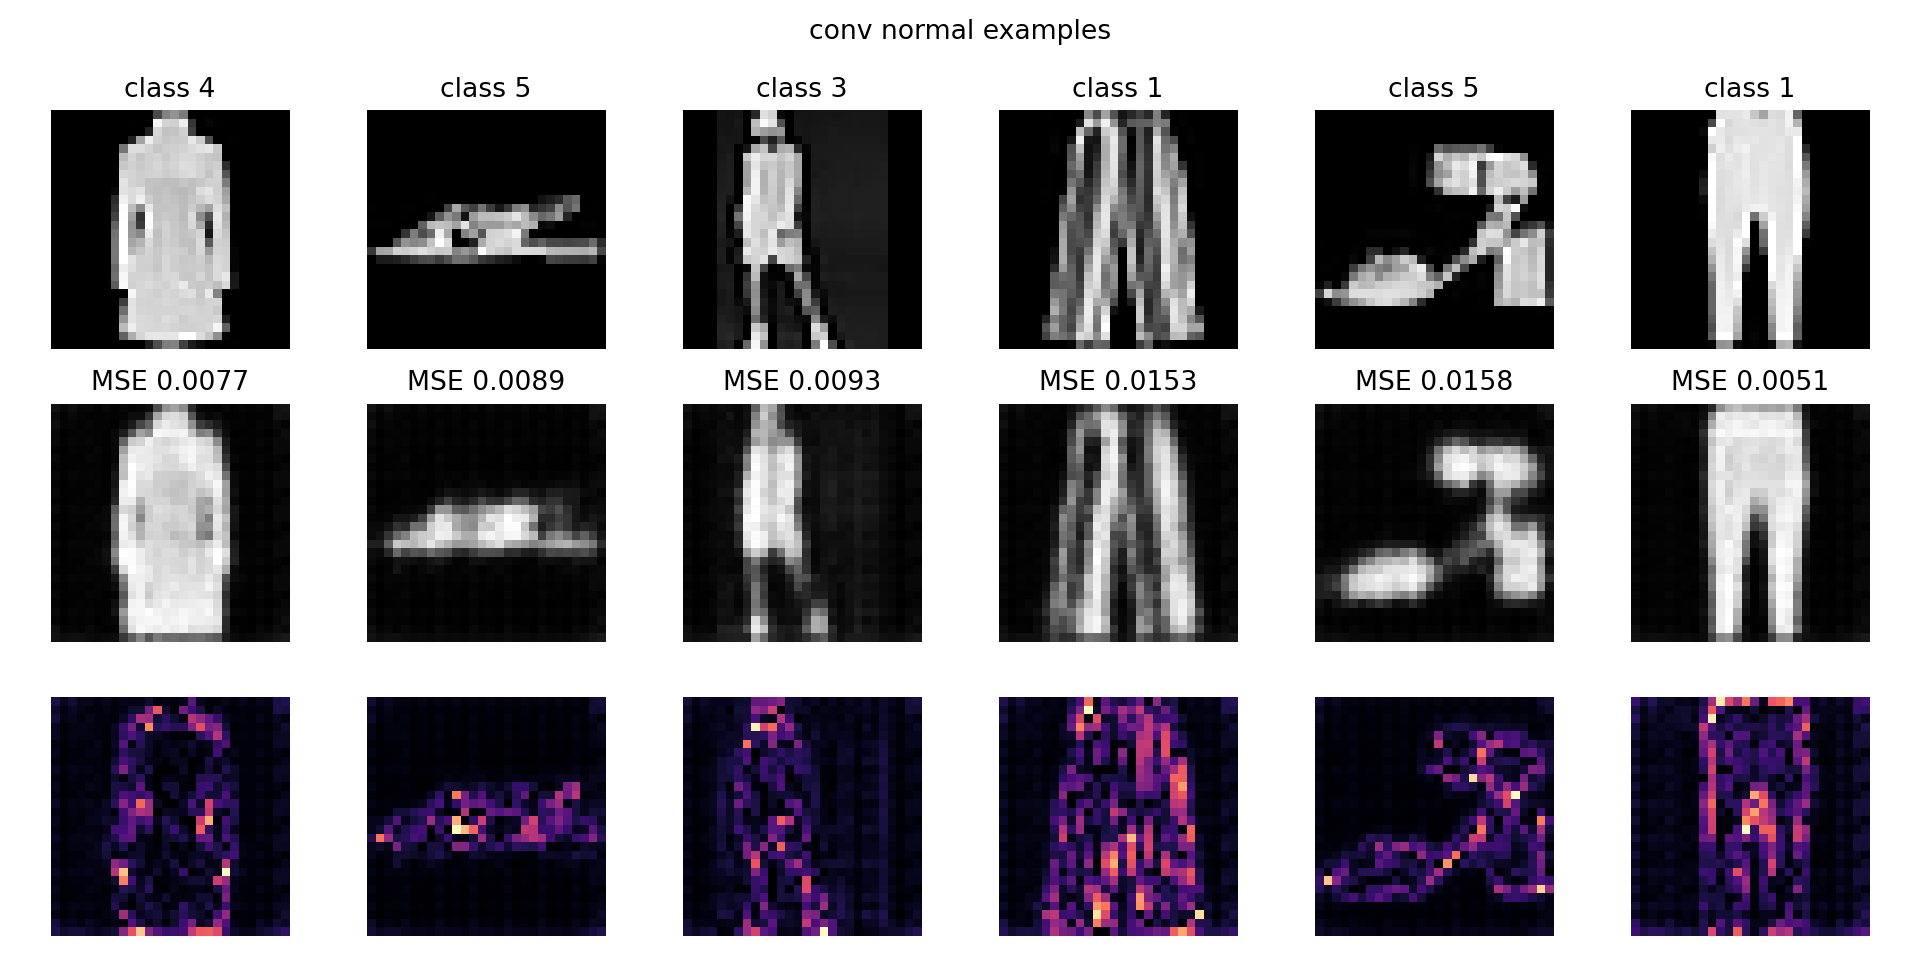

conv_anomaly_examples.png


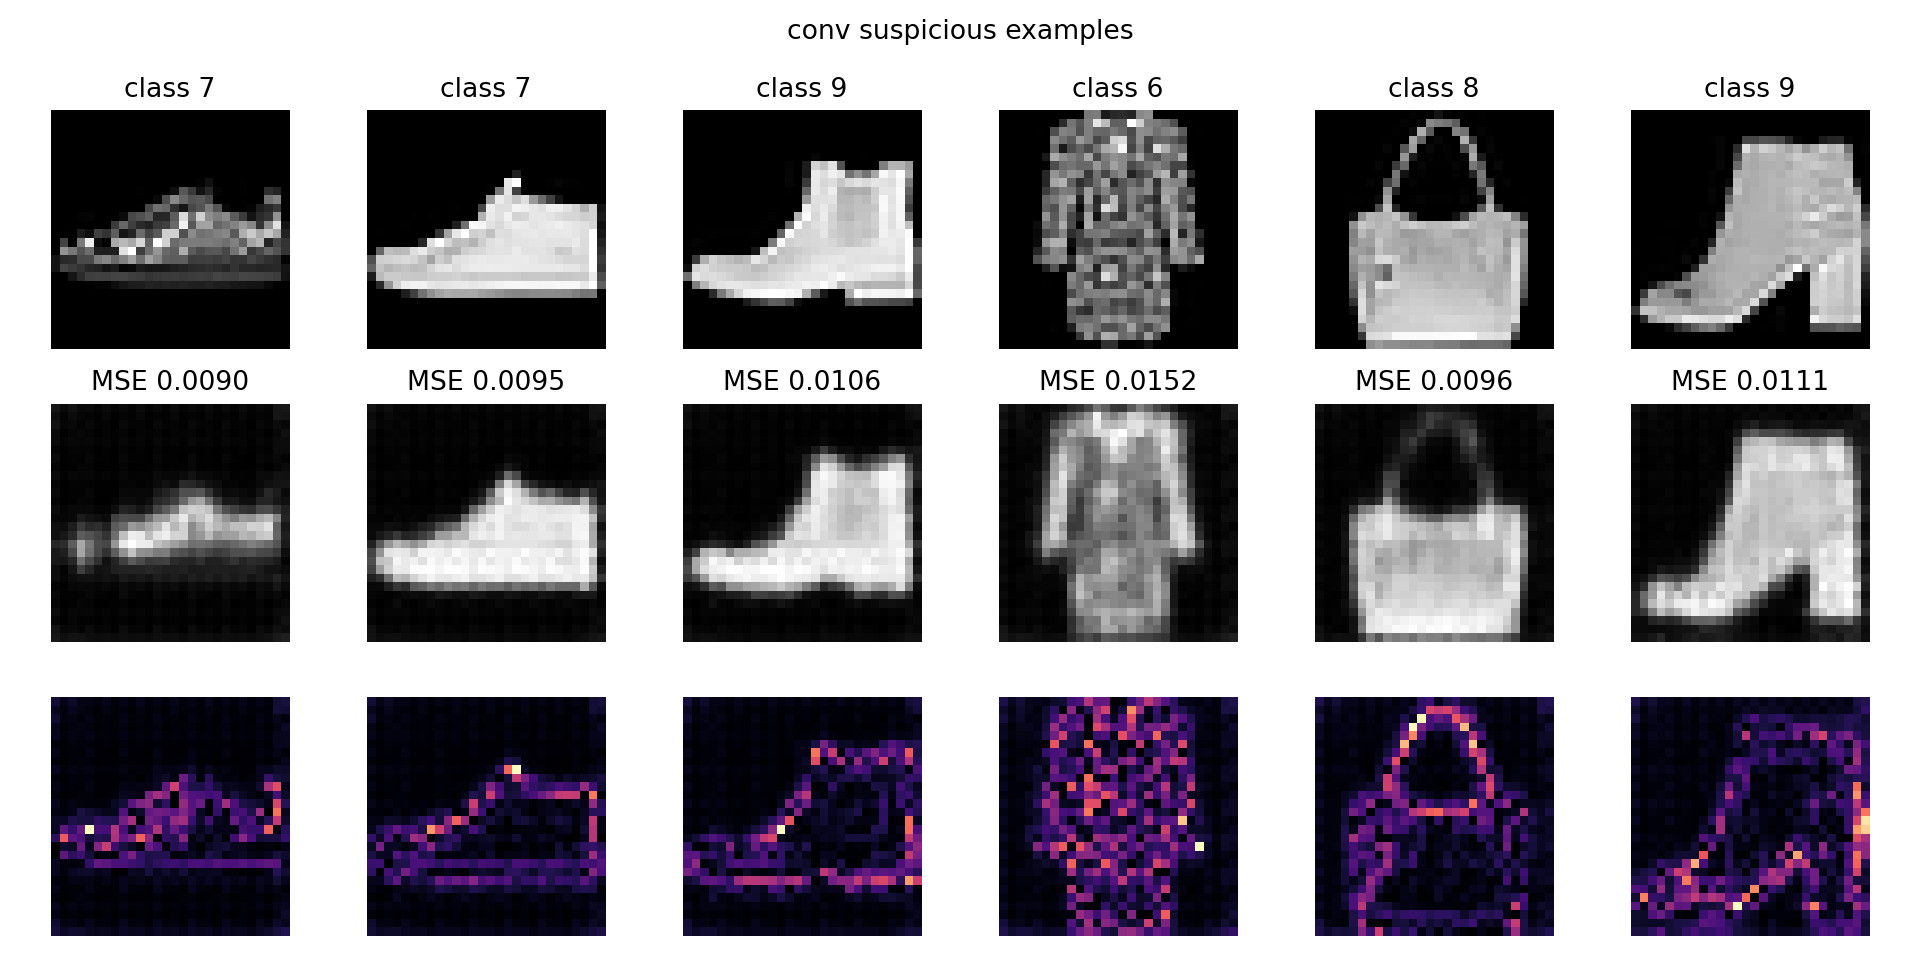

conv_error_distribution.png


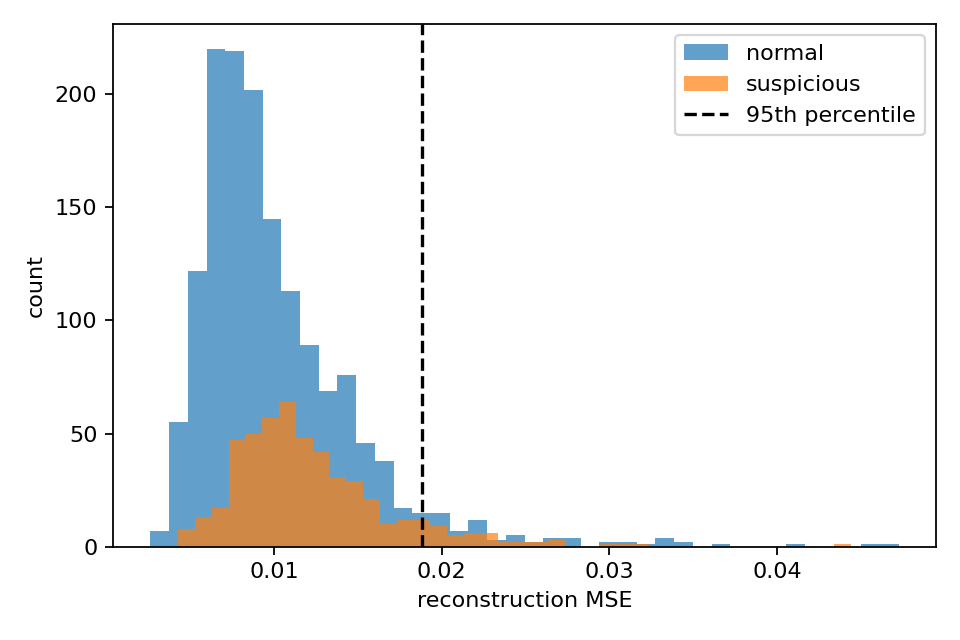

In [18]:
from IPython.display import display, Image
for p in ['conv_loss.png','conv_normal_examples.png','conv_anomaly_examples.png','conv_error_distribution.png']:
    print(p); display(Image(filename='outputs/'+p))

## Reflection

The convolutional bottleneck compresses the input while preserving local spatial patterns such as edges and silhouettes. It is preferable to the dense baseline for image-like thumbnails because convolutional filters reuse parameters across locations. Reconstruction error is useful for triage, but it is not a proof that a document is fraudulent or incorrect: an unusual but valid template can also produce a high error, and a sufficiently similar invalid document may reconstruct well. Fashion-MNIST is only a proxy, so production performance requires real invoice data and threshold calibration.

In [19]:
# Optional: generate the Word report after the experiment
!{sys.executable} make_report.py --metrics outputs/metrics.json --out HW2aCNNautoencoder_report.docx